In [18]:
# Upload the dataset
from google.colab import files

print('Upload dataset: ')
uploaded = files.upload()

Upload dataset: 


Saving netflix_reviews.csv to netflix_reviews.csv


In [19]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

plt.style.use('seaborn-v0_8')

nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',  quiet=True)

True

In [20]:
# Load & rename columns
df = pd.read_csv('netflix_reviews.csv')

df = df.rename(columns={
    'content'              : 'review',
    'score'                : 'rating',
    'thumbsUpCount'        : 'helpful',
    'at'                   : 'date',
    'reviewCreatedVersion' : 'version'
})

df = df.drop(columns=['appVersion'])
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['is_positive_review'] = (df['rating'] >= 4).astype(int)

df.head(1)

,reviewId,userName,review,rating,helpful,version,date,is_positive_review
0,fe09d8ca-d429-4552-931c-c8add030b4ed,Will Sims,being forced to send an email so I can watch a...,1,0,9.68.0 build 2 64148,2026-06-03 08:49:08,0


In [21]:
# Basic checks
print(df.describe())
print('\nUnique values per column:')
print(df.nunique())
print('\nMissing values:')
print(df.isnull().sum())

              rating        helpful                           date  \
count  151801.000000  151801.000000                         151801   
mean        2.874112       8.074901  2022-07-29 17:33:04.285907200   
min         1.000000       0.000000            2018-09-12 07:22:12   
25%         1.000000       0.000000            2020-07-26 08:49:53   
50%         3.000000       0.000000            2022-07-04 13:35:28   
75%         5.000000       1.000000            2024-08-08 16:23:29   
max         5.000000    8032.000000            2026-06-03 08:49:08   
std         1.739444      88.791598                            NaN   

       is_positive_review  
count       151801.000000  
mean             0.426888  
min              0.000000  
25%              0.000000  
50%              0.000000  
75%              1.000000  
max              1.000000  
std              0.494627  

Unique values per column:
reviewId              150161
userName              115093
review                143323
rat

In [23]:
# Cleaning data
df = df.dropna(subset=['review'])
df['review_length'] = df['review'].apply(lambda x: len(str(x).split()))

print(f'Total rows     : {len(df)}')
print(f'Duplicate rate : {1 - df["review"].nunique()/len(df):.1%}')

df = df.drop_duplicates(subset='review').reset_index(drop=True)
print(f'New Shape          : {df.shape}')

Total rows     : 143323
Duplicate rate : 0.0%
New Shape          : (143323, 9)


Rating distribution:
 rating
1    58599
2    12942
3    14000
4    15753
5    42029
Name: count, dtype: int64

Positive rate: 0.403


/tmp/ipykernel_4086/436565100.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df, palette='Blues')


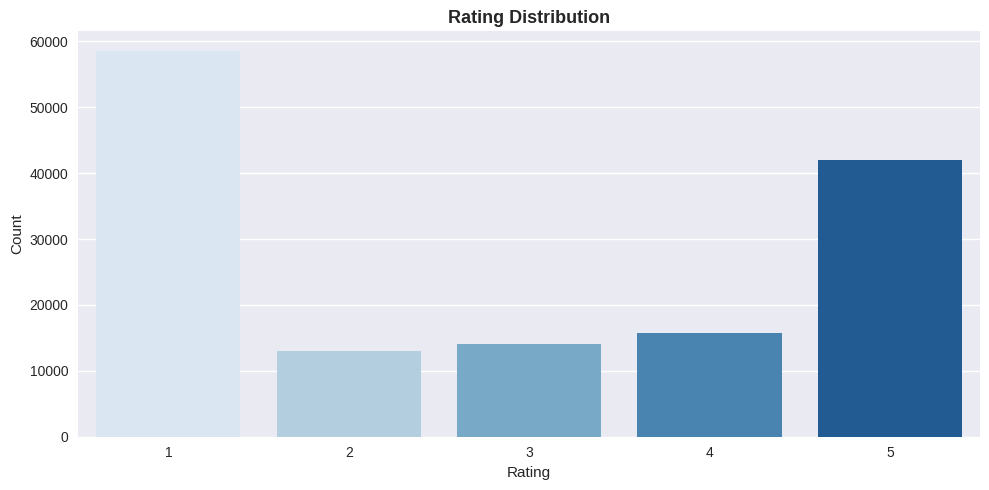

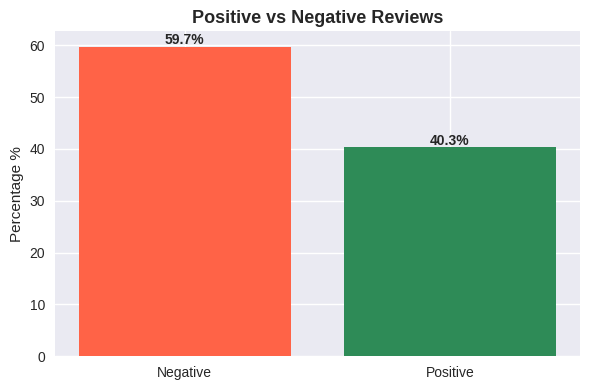

In [25]:
# Rating distribution
print('Rating distribution:\n', df['rating'].value_counts().sort_index())
print('\nPositive rate:', df['is_positive_review'].mean().round(3))

plt.figure(figsize=(10, 5))
sns.countplot(x='rating', data=df, palette='Blues')
plt.title('Rating Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

review_proportion = df['is_positive_review'].value_counts(normalize=True) * 100

print('\n')
plt.figure(figsize=(6, 4))
plt.bar(['Negative', 'Positive'], review_proportion.sort_index(),
        color=['tomato', 'seagreen'])
plt.title('Positive vs Negative Reviews', fontsize=13, fontweight='bold')
plt.ylabel('Percentage %')
for i, v in enumerate(review_proportion.sort_index()):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

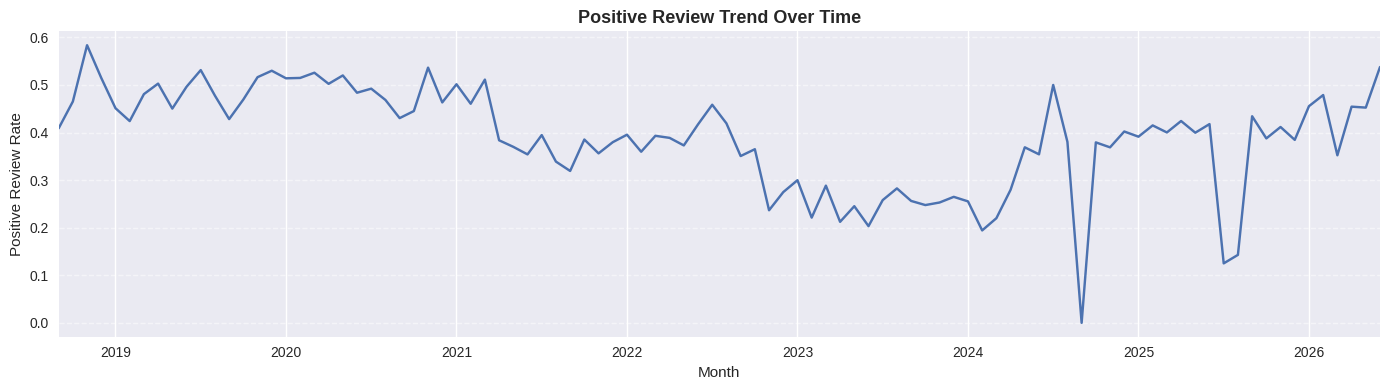

In [26]:
# Sentiment trend over time
df['month'] = df['date'].dt.to_period('M')
sentiment_trend = df.groupby('month')['is_positive_review'].mean()

plt.figure(figsize=(14, 4))
sentiment_trend.plot()
plt.title('Positive Review Trend Over Time', fontsize=13, fontweight='bold')
plt.ylabel('Positive Review Rate')
plt.xlabel('Month')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

/tmp/ipykernel_4086/2035472969.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_positive_review', y='review_length', data=df,


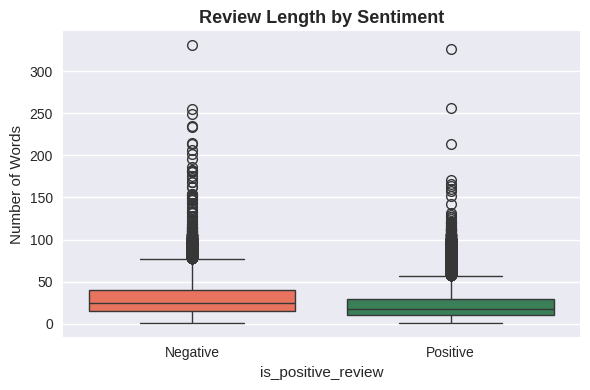

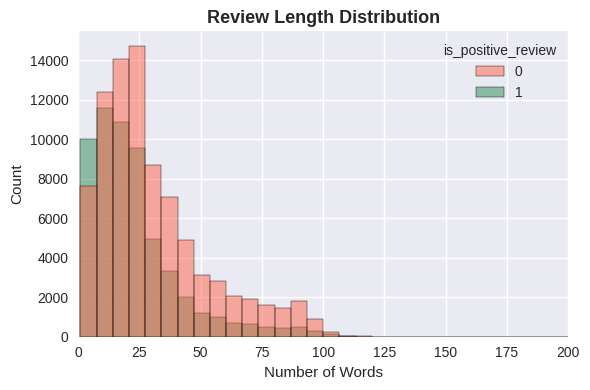

In [27]:
# Review length analysis
plt.figure(figsize=(6, 4))
sns.boxplot(x='is_positive_review', y='review_length', data=df,
            palette=['tomato', 'seagreen'])
plt.title('Review Length by Sentiment', fontsize=13, fontweight='bold')
plt.xticks([0, 1], ['Negative', 'Positive'])
plt.ylabel('Number of Words')
plt.tight_layout()
plt.show()
print('\n')
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x='review_length', hue='is_positive_review',
             bins=50, palette=['tomato', 'seagreen'])
plt.title('Review Length Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Number of Words')
plt.xlim(0, 200)
plt.tight_layout()
plt.show()

In [28]:
# Text preprocessing
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

custom_stopwords = [
    'netflix', 'app', 'show', 'could', 'movie', 'series', 'use', 'used',
    'really', 'already', 'still', 'get', 'one', 'also', 'would', 'please',
    'ill', 'doesnt', 'dont', 'cant', 'wont', 'ive', 'im', 'thats', 'us', 'even'
]
stop_words.update(custom_stopwords)

def clean_text(text):
    if pd.isnull(text):
        return ''
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words]
    return ' '.join(tokens)

df['clean_review'] = df['review'].apply(clean_text)
df = df[df['clean_review'].str.strip() != ''].reset_index(drop=True)

print('Shape after cleaning:', df.shape)
df[['review', 'clean_review', 'rating', 'is_positive_review']].sample(5, random_state=42)

Shape after cleaning: (142542, 11)


,review,clean_review,rating,is_positive_review
140538,Triple Frontier: Extremely impressed. More of ...,triple frontier extremely impressed,5,1
129918,This is better then hulu because you can wach ...,better hulu wach new old movie hulu old movie ...,5,1
4727,Excellent ! 🔥,excellent,5,1
130907,Very efficient. Hassle free. Old age friendly ...,efficient hassle free old age friendly,5,1
93587,It just keeps loading on mobile. When I open p...,keep loading mobile open pc fine might problem,1,0


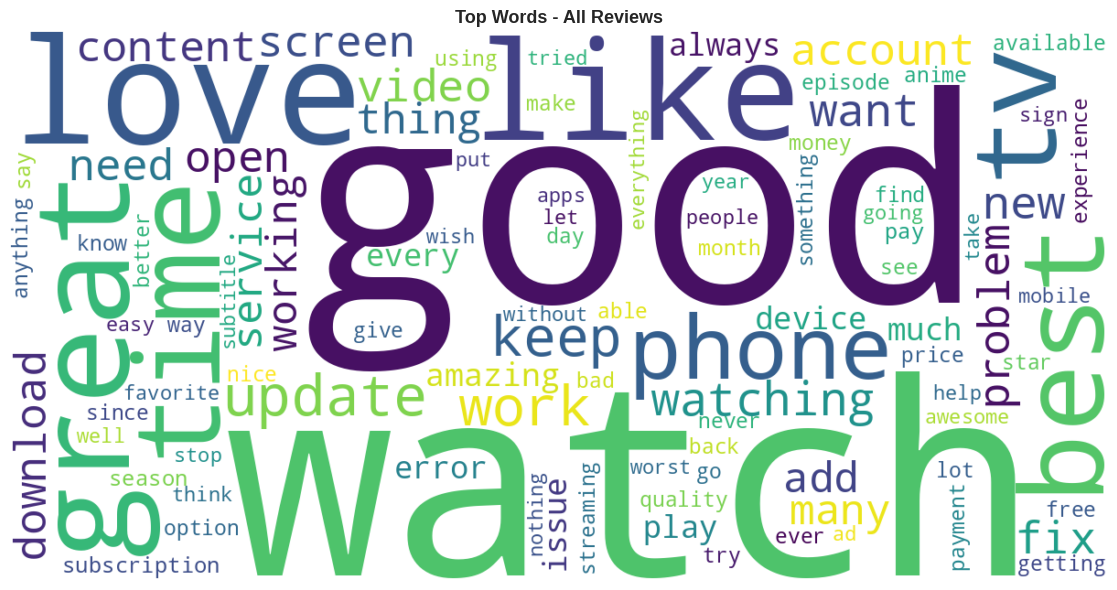

In [29]:
# Word clouds
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_all    = TfidfVectorizer(max_features=1000, ngram_range=(1,2), stop_words=list(stop_words))
tfidf_matrix = tfidf_all.fit_transform(df['clean_review'])
tfidf_sums   = np.sum(tfidf_matrix.toarray(), axis=0)
tfidf_df     = pd.DataFrame({'word': tfidf_all.get_feature_names_out(), 'tfidf_sum': tfidf_sums})
tfidf_df     = tfidf_df.sort_values('tfidf_sum', ascending=False)

wc = WordCloud(width=1200, height=600, background_color='white',
               max_words=100, collocations=False
               ).generate_from_frequencies(dict(zip(tfidf_df['word'], tfidf_df['tfidf_sum'])))

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Top Words - All Reviews', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

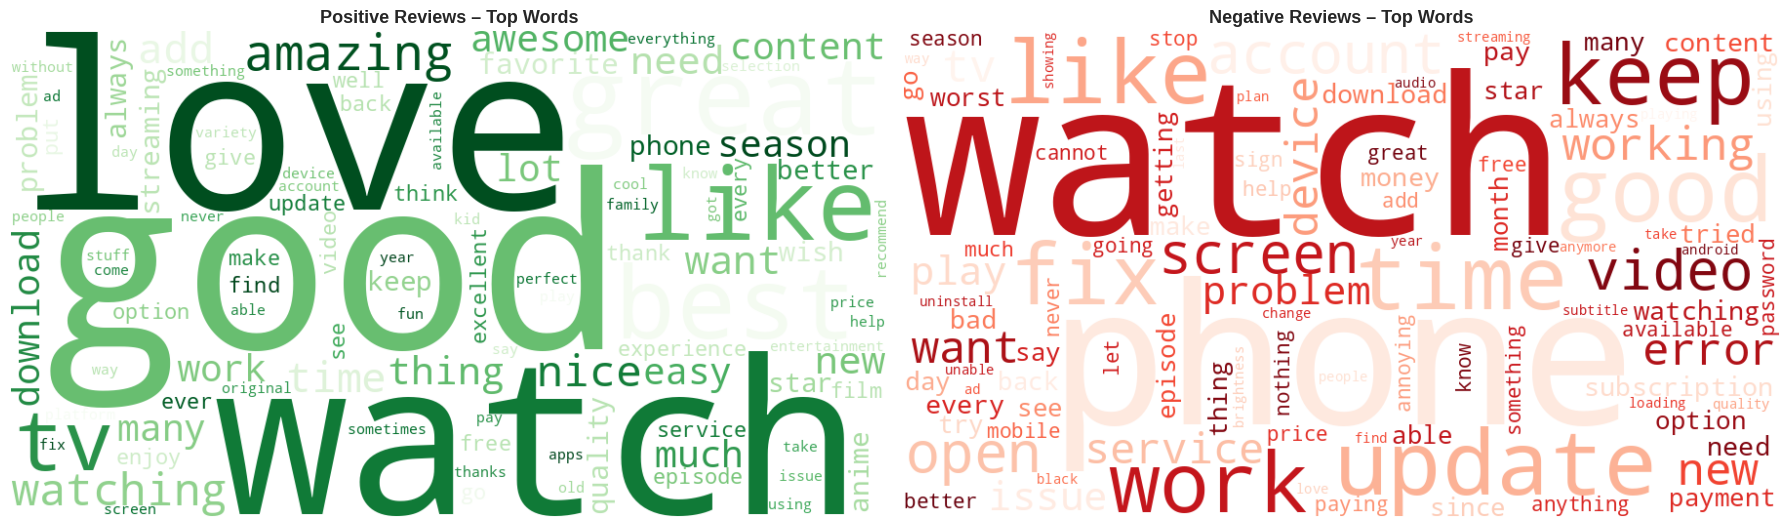

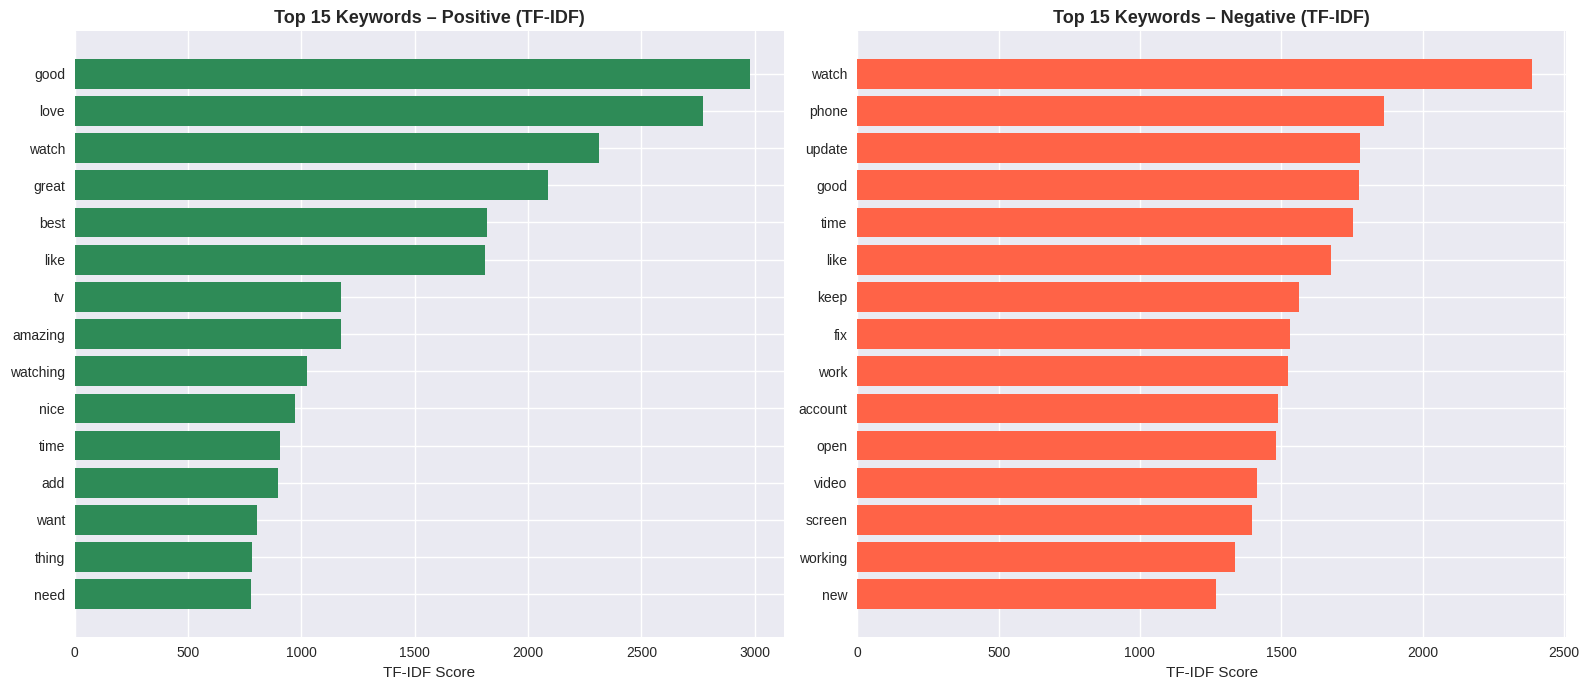

In [31]:
# Positive vs Negative word clouds & bar charts
df_pos = df[df['is_positive_review'] == 1]
df_neg = df[df['is_positive_review'] == 0]

def get_tfidf_df(texts, stop_words):
    vec = TfidfVectorizer(max_features=1000, ngram_range=(1,2), stop_words=list(stop_words))
    mat = vec.fit_transform(texts)
    sums = np.sum(mat.toarray(), axis=0)
    return pd.DataFrame({'word': vec.get_feature_names_out(), 'tfidf_sum': sums}
                        ).sort_values('tfidf_sum', ascending=False)

tfidf_pos_df = get_tfidf_df(df_pos['clean_review'], stop_words)
tfidf_neg_df = get_tfidf_df(df_neg['clean_review'], stop_words)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, tfidf_data, title, cmap in zip(
    axes,
    [tfidf_pos_df, tfidf_neg_df],
    ['Positive Reviews – Top Words', 'Negative Reviews – Top Words'],
    ['Greens', 'Reds']
):
    wc = WordCloud(width=900, height=500, background_color='white',
                   max_words=100, collocations=False, colormap=cmap
                   ).generate_from_frequencies(dict(zip(tfidf_data['word'], tfidf_data['tfidf_sum'])))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
#print('\n')
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, tfidf_data, title, color in zip(
    axes,
    [tfidf_pos_df.head(15).sort_values('tfidf_sum'),
     tfidf_neg_df.head(15).sort_values('tfidf_sum')],
    ['Top 15 Keywords – Positive (TF-IDF)', 'Top 15 Keywords – Negative (TF-IDF)'],
    ['seagreen', 'tomato']
):
    ax.barh(tfidf_data['word'], tfidf_data['tfidf_sum'], color=color)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('TF-IDF Score')
plt.tight_layout()
plt.show()

In [32]:
# Model building (4 classifiers)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import MinMaxScaler
from scipy.sparse import hstack, csr_matrix

model_df = df[['clean_review', 'review_length', 'is_positive_review']].copy()

train_df, test_df = train_test_split(
    model_df, test_size=0.2, random_state=42, stratify=model_df['is_positive_review']
)

X_text_train = train_df['clean_review']
X_text_test  = test_df['clean_review']
y_train      = train_df['is_positive_review']
y_test       = test_df['is_positive_review']

tfidf_model   = TfidfVectorizer(max_features=1000, ngram_range=(1,2), stop_words=list(stop_words))
X_train_tfidf = tfidf_model.fit_transform(X_text_train)
X_test_tfidf  = tfidf_model.transform(X_text_test)

scaler              = MinMaxScaler()
length_train_scaled = scaler.fit_transform(train_df[['review_length']].values)
length_test_scaled  = scaler.transform(test_df[['review_length']].values)

X_train = hstack([X_train_tfidf, csr_matrix(length_train_scaled)])
X_test  = hstack([X_test_tfidf,  csr_matrix(length_test_scaled)])

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Naive Bayes'        : MultinomialNB(),
    'Linear SVM'         : LinearSVC(class_weight='balanced', random_state=42, max_iter=2000),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                                   random_state=42, n_jobs=-1)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'model'   : model,
        'y_pred'  : y_pred,
        'f1_macro': f1_score(y_test, y_pred, average='macro'),
        'f1_neg'  : f1_score(y_test, y_pred, pos_label=0),
        'f1_pos'  : f1_score(y_test, y_pred, pos_label=1),
    }
    print(f"\n{'─'*45}\n  {name}\n{'─'*45}")
    print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))


─────────────────────────────────────────────
  Logistic Regression
─────────────────────────────────────────────
              precision    recall  f1-score   support

    Negative       0.89      0.86      0.87     17052
    Positive       0.80      0.84      0.81     11457

    accuracy                           0.85     28509
   macro avg       0.84      0.85      0.84     28509
weighted avg       0.85      0.85      0.85     28509


─────────────────────────────────────────────
  Naive Bayes
─────────────────────────────────────────────
              precision    recall  f1-score   support

    Negative       0.83      0.89      0.86     17052
    Positive       0.82      0.74      0.78     11457

    accuracy                           0.83     28509
   macro avg       0.83      0.81      0.82     28509
weighted avg       0.83      0.83      0.83     28509


─────────────────────────────────────────────
  Linear SVM
─────────────────────────────────────────────
              prec

In [13]:
# Hyperparameter tuning (Logistic Regression)
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C'      : [0.01, 0.1, 1, 10, 100],
    'solver' : ['lbfgs', 'liblinear'],
    'penalty': ['l2']
}

grid_search = GridSearchCV(
    estimator  = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'f1_macro',
    n_jobs     = -1,
    verbose    = 1
)
grid_search.fit(X_train, y_train)

print(f'Best parameters : {grid_search.best_params_}')
print(f'Best CV F1 Macro: {grid_search.best_score_:.4f}')

best_lr      = grid_search.best_estimator_
y_pred_tuned = best_lr.predict(X_test)
tuned_f1     = f1_score(y_test, y_pred_tuned, average='macro')

print(f'\nTuned Logistic Regression')
print(classification_report(y_test, y_pred_tuned, target_names=['Negative', 'Positive']))
print(f'Original F1 Macro : {results["Logistic Regression"]["f1_macro"]:.4f}')
print(f'Tuned F1 Macro    : {tuned_f1:.4f}')
print(f'Improvement       : +{tuned_f1 - results["Logistic Regression"]["f1_macro"]:.4f}')

comparison_df = pd.DataFrame({
    'Model'       : list(results.keys()),
    'F1 Macro'    : [v['f1_macro'] for v in results.values()],
    'F1 Negative' : [v['f1_neg']   for v in results.values()],
    'F1 Positive' : [v['f1_pos']   for v in results.values()],
}).sort_values('F1 Macro', ascending=False)

print(f"\nBest model: {comparison_df.iloc[0]['Model']} "
      f"(F1 Macro: {comparison_df.iloc[0]['F1 Macro']:.3f})")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters : {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV F1 Macro: 0.8430

Tuned Logistic Regression
              precision    recall  f1-score   support

    Negative       0.89      0.86      0.87     17052
    Positive       0.80      0.84      0.81     11457

    accuracy                           0.85     28509
   macro avg       0.84      0.85      0.84     28509
weighted avg       0.85      0.85      0.85     28509

Original F1 Macro : 0.8425
Tuned F1 Macro    : 0.8425
Improvement       : +0.0000

Best model: Logistic Regression (F1 Macro: 0.843)


In [34]:
# Saving model
import pickle

with open('sentiment_model.pkl', 'wb') as f:
    pickle.dump({
        'model'  : best_lr,
        'tfidf'  : tfidf_model,
        'scaler' : scaler
    }, f)

df.to_csv('netflix_reviews_clean.csv', index=False)
print('Saved: sentiment_model.pkl')
print('Saved: netflix_reviews_clean.csv')

Saved: sentiment_model.pkl
Saved: netflix_reviews_clean.csv


In [36]:
# Prepare BI dataset
issue_keywords = ['crash', 'bug', 'error', 'freeze', 'slow', 'fix', 'broken', 'fail', 'stop']
df['has_issue_flag'] = df['review'].str.lower().apply(
    lambda x: 1 if any(k in str(x) for k in issue_keywords) else 0
)

df['year']         = df['date'].dt.year
df['quarter']      = df['date'].dt.quarter
df['year_quarter'] = df['year'].astype(str) + ' Q' + df['quarter'].astype(str)
df['month_name']   = df['date'].dt.strftime('%b %Y')

df_bi = df.drop(columns=['month', 'clean_review', 'reviewId', 'userName'])

print('Final columns:', df_bi.columns.tolist())
print('Shape:', df_bi.shape)
print('Issue flag rate:', df_bi['has_issue_flag'].mean().round(3))

df_bi.to_csv('netflix_reviews_bi.csv', index=False)
print('Saved: netflix_reviews_bi.csv')

Final columns: ['review', 'rating', 'helpful', 'version', 'date', 'is_positive_review', 'review_length', 'has_issue_flag', 'year', 'quarter', 'year_quarter', 'month_name']
Shape: (142542, 12)
Issue flag rate: 0.173
Saved: netflix_reviews_bi.csv
